# 03 - Geliştirilmiş Model: Lag Features + Endpoint Encoding

Bu notebook'ta mevcut feature setine ek olarak:
- **Lag features**: geçmiş response_time_ms değerleri (t-1, t-2, t-3)
- **Rolling istatistikler**: son 5 ve 10 penceredeki ortalama ve standart sapma
- **Endpoint encoding**: endpoint türü kategorik değişkeni

eklenerek model performansı iyileştirilmektedir.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Veri Yükleme

In [2]:
df = pd.read_csv("../data/raw/request_level_data.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Veri boyutu: {df.shape}")
print(f"Kolonlar: {df.columns.tolist()}")

Veri boyutu: (29209, 14)
Kolonlar: ['request_id', 'timestamp', 'scenario', 'endpoint_name', 'endpoint_path', 'payload_size', 'response_time_ms', 'status_code', 'active_requests', 'rps_10s', 'requests_last_60s', 'client_send_ts', 'client_receive_ts', 'client_observed_latency_ms']


## Feature Engineering

### 1. Lag Features
Geçmiş response_time_ms değerleri direkt feature olarak ekleniyor.
Sezgi: az önce yüksek gecikme varsa, bir sonraki istek de yüksek gecikme yaşama ihtimali yüksek.

In [3]:
# Lag features: t-1, t-2, t-3 response time
for lag in [1, 2, 3]:
    df[f"response_time_lag_{lag}"] = df["response_time_ms"].shift(lag)

# Rolling istatistikler
df["response_time_roll_mean_5"]  = df["response_time_ms"].shift(1).rolling(5).mean()
df["response_time_roll_mean_10"] = df["response_time_ms"].shift(1).rolling(10).mean()
df["response_time_roll_std_5"]   = df["response_time_ms"].shift(1).rolling(5).std()

# Endpoint encoding
le = LabelEncoder()
df["endpoint_encoded"] = le.fit_transform(df["endpoint_name"])
print("Endpoint mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Lag feature'lar NaN içereceğinden ilk satırları düşür
df = df.dropna().reset_index(drop=True)
print(f"NaN temizlendikten sonra veri boyutu: {df.shape}")

Endpoint mapping: {'orders': np.int64(0), 'reports': np.int64(1), 'search': np.int64(2), 'users': np.int64(3)}
NaN temizlendikten sonra veri boyutu: (29199, 21)


### Feature Listesi

In [4]:
features_enhanced = [
    # Orijinal feature'lar
    "payload_size",
    "active_requests",
    "rps_10s",
    "requests_last_60s",
    # Lag features
    "response_time_lag_1",
    "response_time_lag_2",
    "response_time_lag_3",
    # Rolling istatistikler
    "response_time_roll_mean_5",
    "response_time_roll_mean_10",
    "response_time_roll_std_5",
    # Endpoint türü
    "endpoint_encoded"
]

target = "response_time_ms"

print(f"Toplam feature sayısı: {len(features_enhanced)}")
print(features_enhanced)

Toplam feature sayısı: 11
['payload_size', 'active_requests', 'rps_10s', 'requests_last_60s', 'response_time_lag_1', 'response_time_lag_2', 'response_time_lag_3', 'response_time_roll_mean_5', 'response_time_roll_mean_10', 'response_time_roll_std_5', 'endpoint_encoded']


## Sliding Window

In [5]:
def create_window(df, features, target, window_size):
    X, y = [], []
    for i in range(len(df) - window_size):
        X.append(df[features].iloc[i:i+window_size].values)
        y.append(df[target].iloc[i+window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 10
X, y = create_window(df, features_enhanced, target, WINDOW_SIZE)
X_flat = X.reshape(X.shape[0], -1)

split = int(len(X_flat) * 0.8)
X_train, X_test = X_flat[:split], X_flat[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (23351, 110), Test: (5838, 110)


## Model Eğitimi

In [6]:
def evaluate(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "MAE":  round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "R2":   round(r2_score(y_true, y_pred), 4)
    }

results = []

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results.append(evaluate(y_test, y_pred_lr, "Linear Regression (enhanced)"))
print("LR tamamlandı.")

# Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append(evaluate(y_test, y_pred_rf, "Random Forest (enhanced)"))
print("RF tamamlandı.")

results_df = pd.DataFrame(results).set_index("Model")
print("\n", results_df.to_string())
results_df

LR tamamlandı.
RF tamamlandı.

                                  MAE    RMSE      R2
Model                                               
Linear Regression (enhanced)  123.71  178.91  0.1908
Random Forest (enhanced)       88.17  152.82  0.4096


,MAE,RMSE,R2
Model,,,
Linear Regression (enhanced),123.71,178.91,0.1908
Random Forest (enhanced),88.17,152.82,0.4096


## Önceki Sonuçlarla Karşılaştırma

In [7]:
# Önceki sonuçlar (02-model-training-fixed.ipynb ve 03-lstm-model.ipynb'den)
prev_results = [
    {"Model": "LR (baseline)",  "MAE": 147.21, "RMSE": 196.44, "R2": 0.0242},
    {"Model": "RF (baseline)",  "MAE": 146.37, "RMSE": 196.56, "R2": 0.0230},
    {"Model": "LSTM",           "MAE": 121.23, "RMSE": 177.79, "R2": 0.2008},
    {"Model": "LR (enhanced)",  "MAE": results_df.loc["Linear Regression (enhanced)", "MAE"],
                                "RMSE": results_df.loc["Linear Regression (enhanced)", "RMSE"],
                                "R2":   results_df.loc["Linear Regression (enhanced)", "R2"]},
    {"Model": "RF (enhanced)",  "MAE": results_df.loc["Random Forest (enhanced)", "MAE"],
                                "RMSE": results_df.loc["Random Forest (enhanced)", "RMSE"],
                                "R2":   results_df.loc["Random Forest (enhanced)", "R2"]},
]

full_comparison = pd.DataFrame(prev_results).set_index("Model")
print(full_comparison.to_string())
full_comparison

                  MAE    RMSE      R2
Model                                
LR (baseline)  147.21  196.44  0.0242
RF (baseline)  146.37  196.56  0.0230
LSTM           121.23  177.79  0.2008
LR (enhanced)  123.71  178.91  0.1908
RF (enhanced)   88.17  152.82  0.4096


,MAE,RMSE,R2
Model,,,
LR (baseline),147.21,196.44,0.0242
RF (baseline),146.37,196.56,0.0230
LSTM,121.23,177.79,0.2008
LR (enhanced),123.71,178.91,0.1908
RF (enhanced),88.17,152.82,0.4096


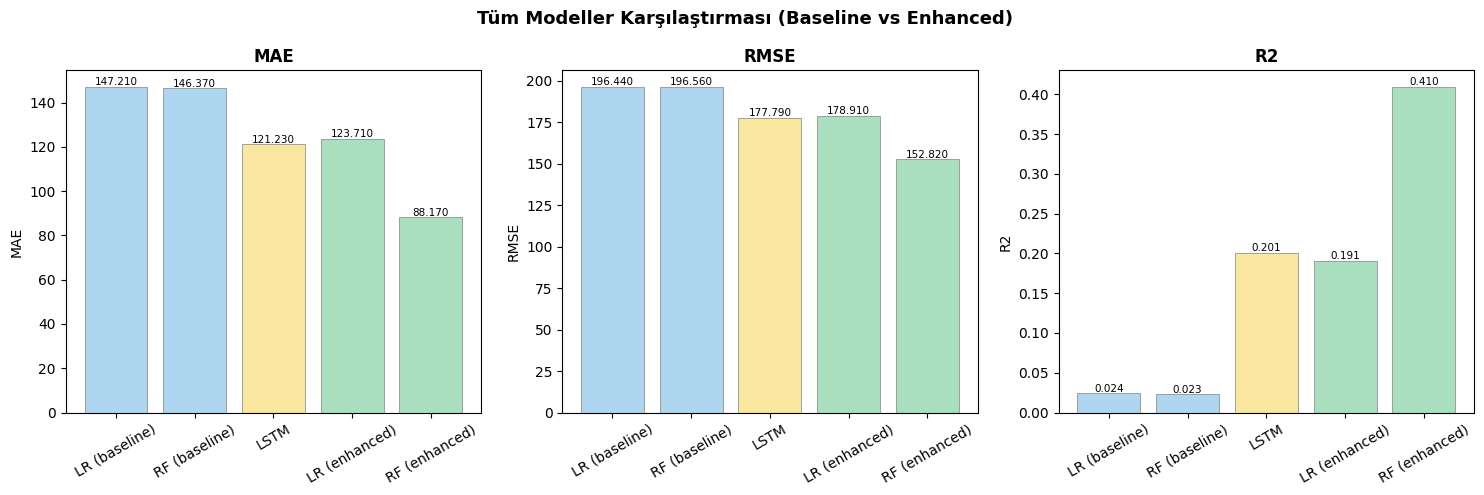

In [8]:
# Karşılaştırma grafiği
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ["MAE", "RMSE", "R2"]
colors_map = {
    "LR (baseline)": "#aed6f1",
    "RF (baseline)": "#aed6f1",
    "LSTM":          "#f9e79f",
    "LR (enhanced)": "#a9dfbf",
    "RF (enhanced)": "#a9dfbf",
}

for ax, metric in zip(axes, metrics):
    vals = full_comparison[metric]
    colors = [colors_map[m] for m in vals.index]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='gray', linewidth=0.5)
    ax.set_title(f"{metric}", fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005 * max(vals.values),
                f"{val:.3f}", ha='center', fontsize=7.5)

plt.suptitle("Tüm Modeller Karşılaştırması (Baseline vs Enhanced)", fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs("../outputs", exist_ok=True)
plt.savefig("../outputs/full_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance (Enhanced RF)

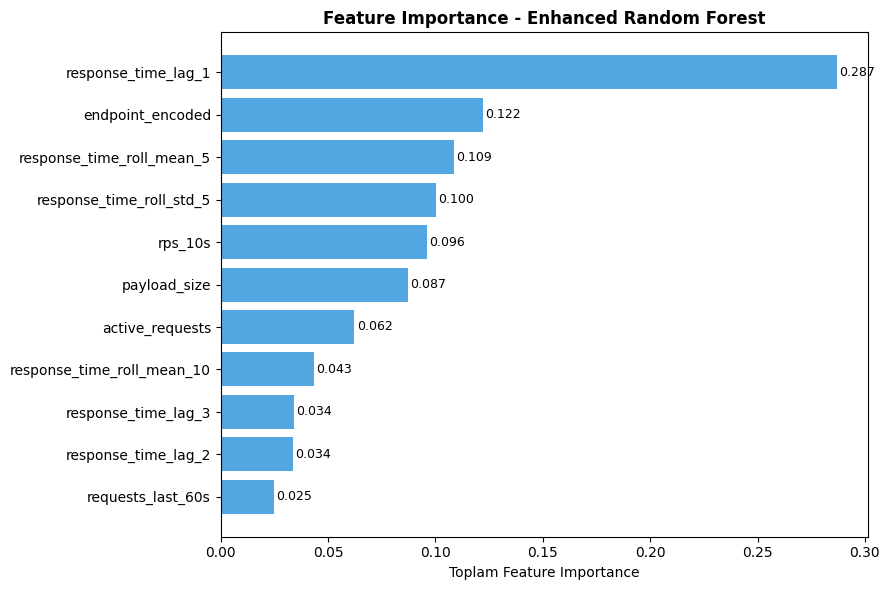


En önemli 5 feature:
                  feature  importance
      response_time_lag_1    0.287039
         endpoint_encoded    0.122122
response_time_roll_mean_5    0.108695
 response_time_roll_std_5    0.100180
                  rps_10s    0.096283


In [9]:
fi_df = pd.DataFrame({
    "feature": features_enhanced,
    "importance": rf.feature_importances_[:len(features_enhanced)]  
    # window'daki her adım için importance toplamı
})

# Her feature için window boyunca toplam importance
fi_grouped = {}
feature_names_flat = []
for t in range(WINDOW_SIZE):
    for f in features_enhanced:
        feature_names_flat.append(f"{f}_t-{WINDOW_SIZE-t}")

importances_all = rf.feature_importances_
fi_grouped = {}
for f in features_enhanced:
    indices = [i for i, name in enumerate(feature_names_flat) if name.startswith(f)]
    fi_grouped[f] = importances_all[indices].sum()

fi_grouped_df = pd.DataFrame(list(fi_grouped.items()), columns=["feature", "importance"])
fi_grouped_df = fi_grouped_df.sort_values("importance", ascending=True)

plt.figure(figsize=(9, 6))
bars = plt.barh(fi_grouped_df["feature"], fi_grouped_df["importance"],
                color="#3498db", alpha=0.85)
plt.xlabel("Toplam Feature Importance")
plt.title("Feature Importance - Enhanced Random Forest", fontweight='bold')
for bar, val in zip(bars, fi_grouped_df["importance"]):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/feature_importance_enhanced.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nEn önemli 5 feature:")
print(fi_grouped_df.sort_values("importance", ascending=False).head().to_string(index=False))

## Model Kaydetme

In [10]:
models_path = "../models"
os.makedirs(models_path, exist_ok=True)

joblib.dump(rf, os.path.join(models_path, "random_forest_enhanced.pkl"))
joblib.dump(lr, os.path.join(models_path, "linear_regression_enhanced.pkl"))
joblib.dump(le, os.path.join(models_path, "label_encoder.pkl"))

config_enhanced = {
    "features": features_enhanced,
    "target": target,
    "window_size": WINDOW_SIZE,
    "endpoint_classes": list(le.classes_)
}
joblib.dump(config_enhanced, os.path.join(models_path, "model_config_enhanced.pkl"))

# 04 notebook için test sonuçları
enhanced_results_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred_rf": y_pred_rf,
    "y_pred_lr": y_pred_lr
})
enhanced_results_df.to_csv("../data/enhanced_test_results.csv", index=False)

print("Kaydedildi:")
print(f"  {models_path}/random_forest_enhanced.pkl")
print(f"  {models_path}/linear_regression_enhanced.pkl")
print(f"  {models_path}/label_encoder.pkl")
print(f"  {models_path}/model_config_enhanced.pkl")
print(f"  ../data/enhanced_test_results.csv")

Kaydedildi:
  ../models/random_forest_enhanced.pkl
  ../models/linear_regression_enhanced.pkl
  ../models/label_encoder.pkl
  ../models/model_config_enhanced.pkl
  ../data/enhanced_test_results.csv
